In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('placement.csv')
print(df.shape)
df.head()


(100, 3)


,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


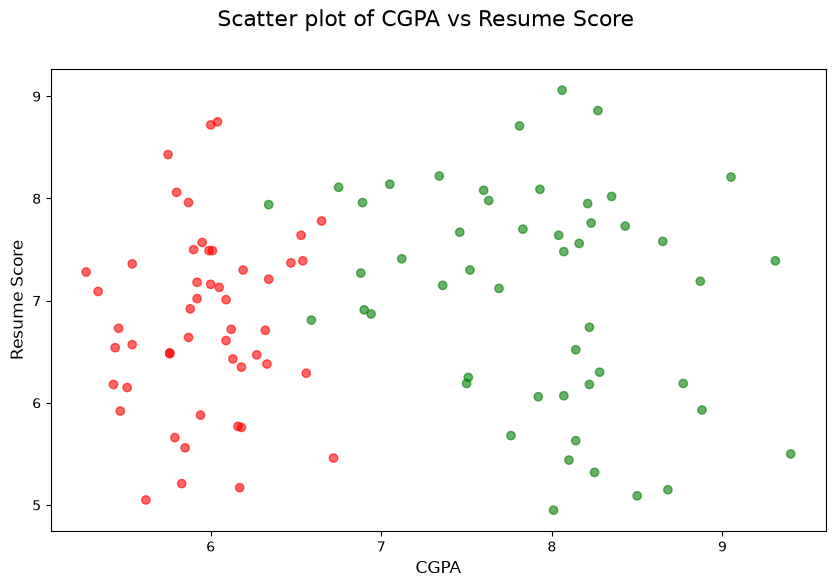

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['cgpa'], df['resume_score'], color=df['placed'].map({1: 'green', 0: 'red'}), alpha=0.6)
fig.suptitle('Scatter plot of CGPA vs Resume Score', fontsize=16)
ax.set_xlabel('CGPA', fontsize=12)
ax.set_ylabel('Resume Score', fontsize=12)

plt.show()

<Axes: xlabel='cgpa', ylabel='resume_score'>

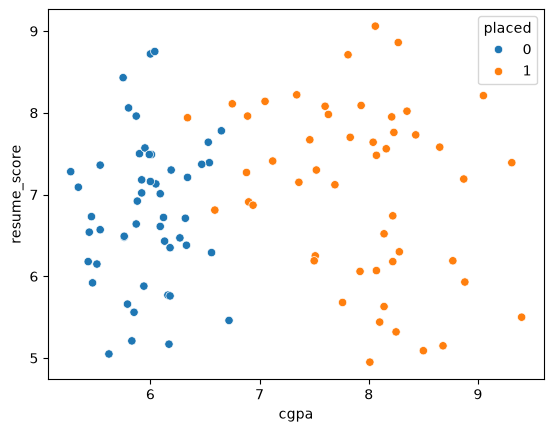

In [16]:
sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed')

In [17]:
X= df.iloc[:,0:2]
Y= df.iloc[:,-1]

In [23]:
from sklearn.linear_model import Perceptron
p = Perceptron()
p.fit(X,Y)
p.coef_, p.intercept_

(array([[ 40.26, -36.  ]]), array([-25.]))

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

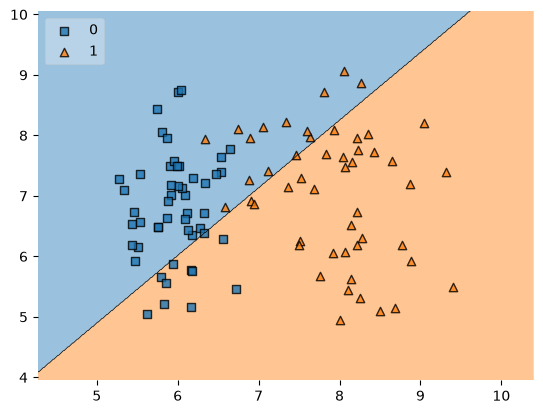

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, Y.values, clf=p, legend=2)


<h1>Building from Scratch</h1>

In [29]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_clusters_per_class=1, n_classes=2, random_state=41, hypercube=False, class_sep=10)


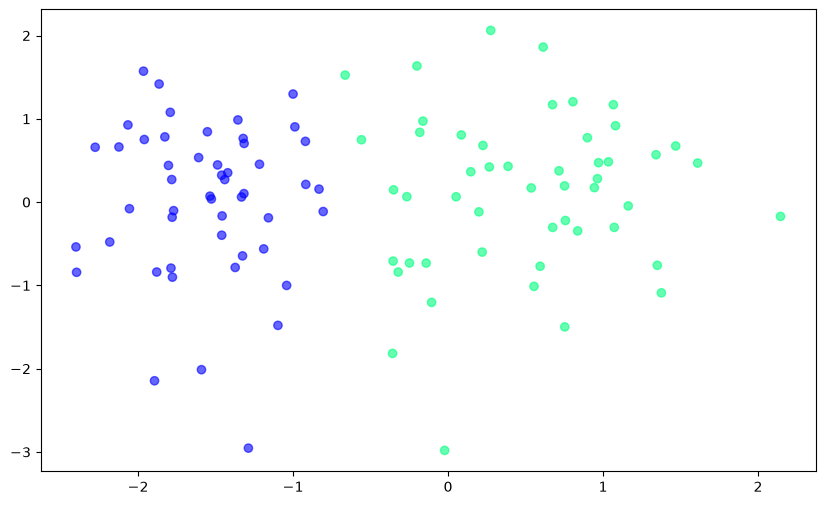

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)

In [34]:
print(X)
print(Y)


[[ 0.19924745 -0.11697552]
 [-0.24882029 -0.73115232]
 [-0.3544904  -0.7081059 ]
 [-1.59086506 -2.01199214]
 [-0.20083951  1.63493163]
 [-0.83241122  0.15599044]
 [-1.79207014  1.07782053]
 [ 0.0856607   0.80626713]
 [-0.55865299  0.74859527]
 [-1.95974262  0.75152794]
 [-1.77828947 -0.90114581]
 [-1.77985853 -0.1815243 ]
 [-0.02194151 -2.98092432]
 [ 0.80563431  1.20500136]
 [-1.82701214  0.78302407]
 [ 0.38730728  0.42968688]
 [-0.14108668 -0.73229726]
 [-1.87955941 -0.83930476]
 [-0.18232911  0.83727062]
 [-1.77059533 -0.10255323]
 [-2.27658028  0.65867001]
 [-2.06519502  0.92649819]
 [-1.31690551  0.10216193]
 [ 1.61043259  0.46886454]
 [-1.21650394  0.45432938]
 [ 0.6139723   1.8613386 ]
 [-1.78760957 -0.79255991]
 [-1.04149161 -1.0004391 ]
 [-2.40067584 -0.53814137]
 [-1.80383452  0.44027716]
 [-1.44075613  0.27047889]
 [ 1.34989978 -0.75869267]
 [ 0.22520167  0.6802322 ]
 [ 0.53688527  0.17018845]
 [ 0.55483459 -1.01121977]
 [-0.32178185 -0.8394709 ]
 [-0.98821248  0.90327412]
 

In [39]:
import numpy as np
print(np.insert(X, 0, 1, axis=1))  # Add bias term

[[ 1.          0.19924745 -0.11697552]
 [ 1.         -0.24882029 -0.73115232]
 [ 1.         -0.3544904  -0.7081059 ]
 [ 1.         -1.59086506 -2.01199214]
 [ 1.         -0.20083951  1.63493163]
 [ 1.         -0.83241122  0.15599044]
 [ 1.         -1.79207014  1.07782053]
 [ 1.          0.0856607   0.80626713]
 [ 1.         -0.55865299  0.74859527]
 [ 1.         -1.95974262  0.75152794]
 [ 1.         -1.77828947 -0.90114581]
 [ 1.         -1.77985853 -0.1815243 ]
 [ 1.         -0.02194151 -2.98092432]
 [ 1.          0.80563431  1.20500136]
 [ 1.         -1.82701214  0.78302407]
 [ 1.          0.38730728  0.42968688]
 [ 1.         -0.14108668 -0.73229726]
 [ 1.         -1.87955941 -0.83930476]
 [ 1.         -0.18232911  0.83727062]
 [ 1.         -1.77059533 -0.10255323]
 [ 1.         -2.27658028  0.65867001]
 [ 1.         -2.06519502  0.92649819]
 [ 1.         -1.31690551  0.10216193]
 [ 1.          1.61043259  0.46886454]
 [ 1.         -1.21650394  0.45432938]
 [ 1.          0.6139723 

In [40]:
def Perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.zeros(X.shape[1])  # Initialize weights
    learning_rate = 0.1
    for epoch in range(1000):  # Number of epochs
        j = np.random.randint(0,100)
        y_hat = step((np.dot(X[j], weights)))  # Prediction
        error = y[j] - y_hat  # Calculate error
        weights += learning_rate * error * X[j]  # Update weights
    return weights[0], weights[1:]  # Return bias and weights

In [42]:
def step(x):
    return 1 if x >= 0 else 0


In [47]:
intercept, coefficients = Perceptron(X, Y)
print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 0.30000000000000004
Coefficients: [0.53090315 0.05493775]


In [48]:
m = -coefficients[0] / coefficients[1]
b = -intercept / coefficients[1]

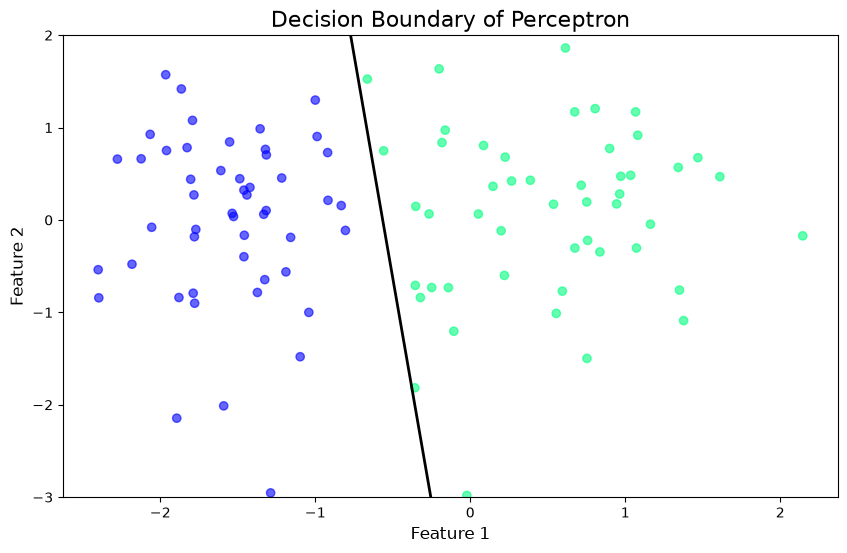

In [54]:
x_input =   np.linspace(-1, 1, 100)
y_input = m * x_input + b

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)
plt.plot(x_input, y_input, color='black', linewidth=2)
plt.title('Decision Boundary of Perceptron', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)   
plt.ylim(-3,2) 

plt.show()

<h1>Drawing Animation</h1>

In [61]:
def perceptron(X,Y):
    m=[]
    b=[]

    X= np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.zeros(X.shape[1])  # Initialize weights
    learning_rate = 0.1
    for epoch in range(1000):  # Number of epochs
        j = np.random.randint(0,100)
        y_hat = step((np.dot(X[j], weights)))  # Prediction
        error = Y[j] - y_hat  # Calculate error
        weights += learning_rate * error * X[j]  # Update weights

        m.append(-(weights[1] / weights[2]))
        b.append(-(weights[0] / weights[2]))
    return m, b


In [62]:
m, b = perceptron(X,Y)

In [64]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

x_i = np.arange(-1, 1, 0.1)
y_input = m[0] * x_i + b[0]

ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)
line,  = ax.plot(x_i, y_input, color='black', linewidth=2)
plt.ylim(-3,2)

def update(i):
    label = 'Epoch {0}'.format(i+1)
    line.set_ydata(m[i] * x_i + b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, frames=200, interval=100, repeat=True)



<IPython.core.display.Javascript object>

AttributeError: 'FuncAnimation' object has no attribute 'show'